Step 1: Load & Understand Dataset

In [ ]:
import pandas as pd

df = pd.read_csv("/content/sample_data/walmart_data.csv")

# Basic structure
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


Step 2: Check Missing Values

In [ ]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


Step 3: Detect Outliers

Method 1: Boxplot

<Axes: xlabel='Purchase'>

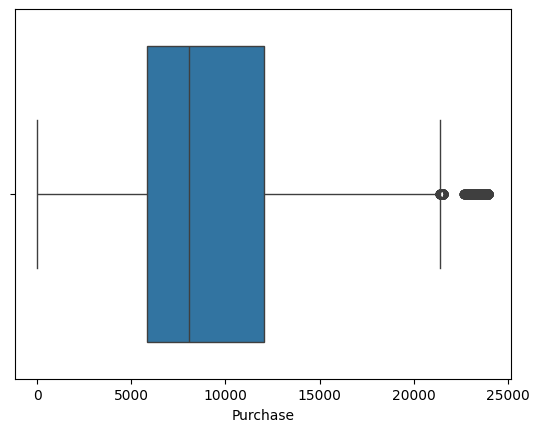

In [ ]:
import seaborn as sns
sns.boxplot(x=df["Purchase"])

Method 2: Compare Mean vs Median

In [ ]:
df["Purchase"].mean()
df["Purchase"].median()

8047.0

Step 4: Gender-Based Spending Analysis

Split data:

In [ ]:
male = df[df["Gender"] == "M"]
female = df[df["Gender"] == "F"]

Compute average:

In [ ]:
male_mean = male["Purchase"].mean()
female_mean = female["Purchase"].mean()

print(male_mean, female_mean)

9437.526040472265 8734.565765155476


Step 5: Central Limit Theorem (CLT)
use CLT to estimate population mean using sample mean.
Step 6: Confidence Interval Calculation

In [ ]:
# For Female Dataset
import numpy as np

mean = female["Purchase"].mean()
std = female["Purchase"].std()
n = len(female)

z = 1.96  # 95% confidence

lower = mean - z * (std / np.sqrt(n))
upper = mean + z * (std / np.sqrt(n))

print(lower, upper)

8709.211081242413 8759.920449068539


In [ ]:
# For Male Dataset
import numpy as np

mean = male["Purchase"].mean()
std = male["Purchase"].std()
n = len(male)

z = 1.96  # 95% confidence

lower = mean - z * (std / np.sqrt(n))
upper = mean + z * (std / np.sqrt(n))

print(lower, upper)

9422.019162420047 9453.032918524483


Step 7: Change Sample Size (CLT Demonstration)

In [ ]:
sample_100 = female["Purchase"].sample(100).mean()
sample_500 = female["Purchase"].sample(500).mean()
sample_1000 = female["Purchase"].sample(1000).mean()
print(sample_100)
print(sample_500)
print(sample_1000)

9293.07
8571.788
9035.631


Step 9: Married vs Unmarried Analysis

In [ ]:
married = df[df["Marital_Status"] == 1]
unmarried = df[df["Marital_Status"] == 0]

married_mean = married["Purchase"].mean()
unmarried_mean = unmarried["Purchase"].mean()
print(married_mean)
print(unmarried_mean)

9261.174574082374
9265.907618921507


Step 10: Age-Based Analysis
Group by Age:

In [ ]:
df.groupby("Age")["Purchase"].mean()

,Purchase
Age,
0-17,8933.464640
18-25,9169.663606
26-35,9252.690633
36-45,9331.350695
46-50,9208.625697
51-55,9534.808031
55+,9336.280459


✅ Dataset Loaded Successfully

🔹 First 5 Rows:
    User_ID Product_ID Gender   Age  Occupation City_Category  \
0  1000001  P00069042      F  0-17          10             A   
1  1000001  P00248942      F  0-17          10             A   
2  1000001  P00087842      F  0-17          10             A   
3  1000001  P00085442      F  0-17          10             A   
4  1000002  P00285442      M   55+          16             C   

  Stay_In_Current_City_Years  Marital_Status  Product_Category  Purchase  
0                          2               0                 3      8370  
1                          2               0                 1     15200  
2                          2               0                12      1422  
3                          2               0                12      1057  
4                         4+               0                 8      7969  

🔹 Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 1

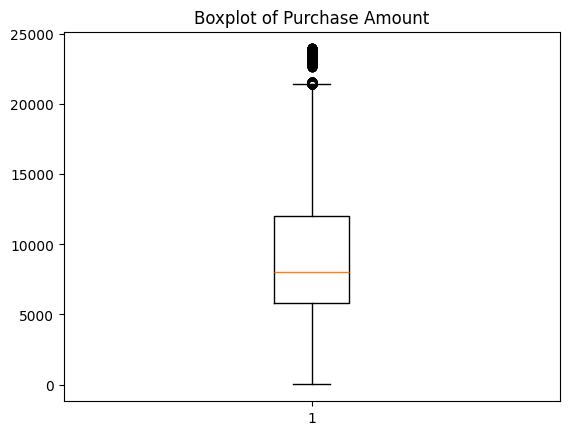


Mean Purchase: 9263.968712959126
Median Purchase: 8047.0

🔹 Average Purchase (Male): 9437.526040472265
🔹 Average Purchase (Female): 8734.565765155476


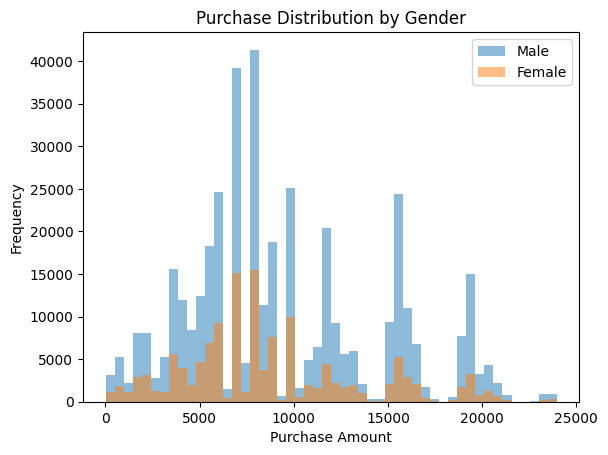


🔹 Male 95% CI: (np.float64(9422.019181136464), np.float64(9453.032899808066))
🔹 Female 95% CI: (np.float64(8709.21117458943), np.float64(8759.92035572152))


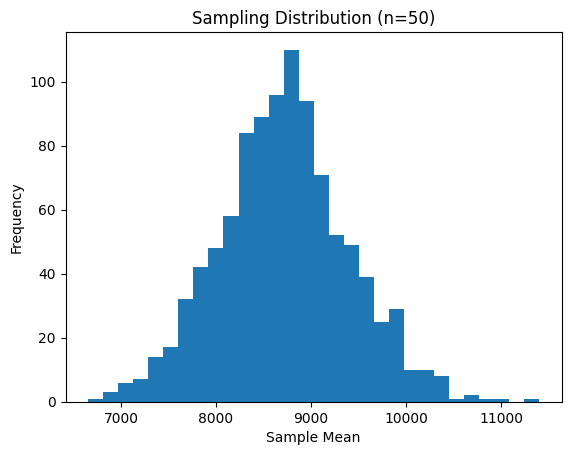

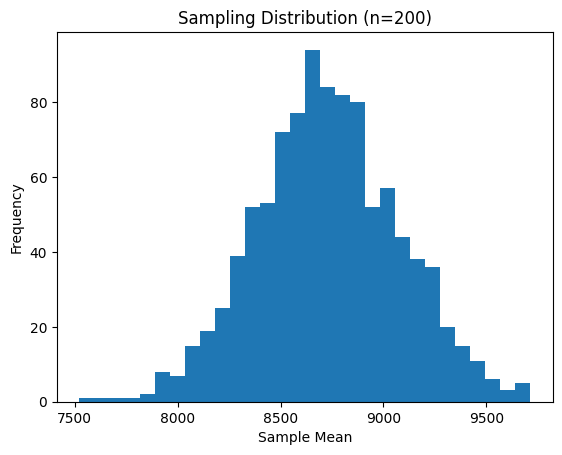

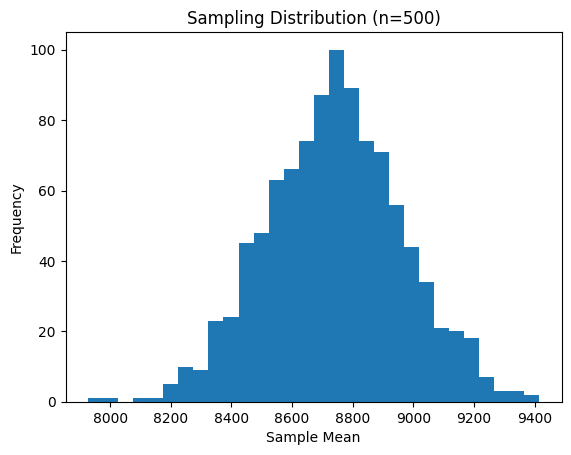


🔹 Married Avg Purchase: 9261.174574082374
🔹 Unmarried Avg Purchase: 9265.907618921507
🔹 Married CI: (np.float64(9240.460092386264), np.float64(9281.889055778483))
🔹 Unmarried CI: (np.float64(9248.616127075364), np.float64(9283.19911076765))

🔹 Purchase by Age Group:
 Age
0-17     8933.464640
18-25    9169.663606
26-35    9252.690633
36-45    9331.350695
46-50    9208.625697
51-55    9534.808031
55+      9336.280459
Name: Purchase, dtype: float64


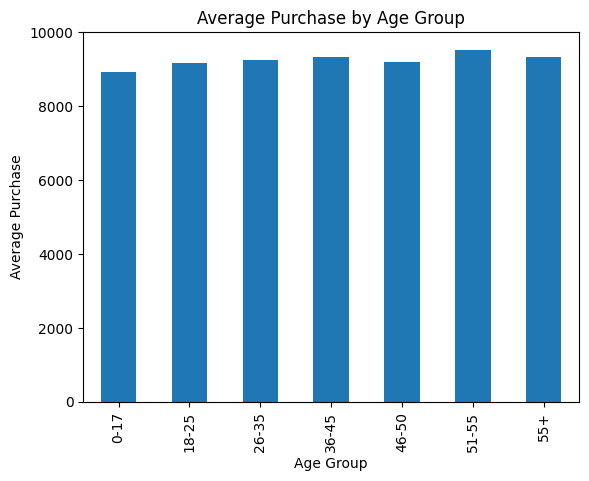

Age 0-17 CI: (np.float64(8851.949171591508), np.float64(9014.98010929844))
Age 55+ CI: (np.float64(9269.299161061219), np.float64(9403.26175783759))
Age 26-35 CI: (np.float64(9231.73333902392), np.float64(9273.647926715856))
Age 46-50 CI: (np.float64(9163.084804071494), np.float64(9254.166590865161))
Age 51-55 CI: (np.float64(9483.99119894781), np.float64(9585.624862972662))
Age 36-45 CI: (np.float64(9301.669000456504), np.float64(9361.032389379243))
Age 18-25 CI: (np.float64(9138.407531227567), np.float64(9200.91968129501))

================ FINAL INSIGHTS ================
✔ Significant difference between Male & Female spending
✔ No significant difference between Married & Unmarried spending

✔ Highest spending age group: 51-55



In [ ]:
# ============================================
#  WALMART CUSTOMER PURCHASE ANALYSIS PROJECT
# ============================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("/content/sample_data/walmart_data.csv")

print("✅ Dataset Loaded Successfully\n")

# ============================================
# BASIC DATA ANALYSIS
# ============================================

print("🔹 First 5 Rows:\n", df.head())
print("\n🔹 Dataset Info:\n")
df.info()

print("\n🔹 Statistical Summary:\n", df.describe())

# ============================================
# CHECK MISSING VALUES
# ============================================

print("\n🔹 Missing Values:\n", df.isnull().sum())

# ============================================
# OUTLIER DETECTION
# ============================================

plt.figure()
plt.boxplot(df["Purchase"])
plt.title("Boxplot of Purchase Amount")
plt.show()

print("\nMean Purchase:", df["Purchase"].mean())
print("Median Purchase:", df["Purchase"].median())

# ============================================
# GENDER ANALYSIS
# ============================================

male = df[df["Gender"] == "M"]
female = df[df["Gender"] == "F"]

male_mean = male["Purchase"].mean()
female_mean = female["Purchase"].mean()

print("\n🔹 Average Purchase (Male):", male_mean)
print("🔹 Average Purchase (Female):", female_mean)

# ============================================
# HISTOGRAM (Distribution)
# ============================================

plt.figure()
plt.hist(male["Purchase"], bins=50, alpha=0.5, label="Male")
plt.hist(female["Purchase"], bins=50, alpha=0.5, label="Female")
plt.legend()
plt.title("Purchase Distribution by Gender")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

# ============================================
# CONFIDENCE INTERVAL FUNCTION
# ============================================

def confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    std = np.std(data)
    n = len(data)

    z_dict = {0.90:1.645, 0.95:1.96, 0.99:2.576}
    z = z_dict[confidence]

    margin_error = z * (std / np.sqrt(n))

    return mean - margin_error, mean + margin_error

# ============================================
# GENDER CONFIDENCE INTERVAL
# ============================================

male_ci = confidence_interval(male["Purchase"])
female_ci = confidence_interval(female["Purchase"])

print("\n🔹 Male 95% CI:", male_ci)
print("🔹 Female 95% CI:", female_ci)

# ============================================
# CLT DEMONSTRATION
# ============================================

def sample_means(data, sample_size, num_samples=1000):
    means = []
    for _ in range(num_samples):
        sample = data.sample(sample_size)
        means.append(sample.mean())
    return means

sample_sizes = [50, 200, 500]

for size in sample_sizes:
    means = sample_means(female["Purchase"], size)

    plt.figure()
    plt.hist(means, bins=30)
    plt.title(f"Sampling Distribution (n={size})")
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.show()

# ============================================
# MARITAL STATUS ANALYSIS
# ============================================

married = df[df["Marital_Status"] == 1]
unmarried = df[df["Marital_Status"] == 0]

married_mean = married["Purchase"].mean()
unmarried_mean = unmarried["Purchase"].mean()

print("\n🔹 Married Avg Purchase:", married_mean)
print("🔹 Unmarried Avg Purchase:", unmarried_mean)

married_ci = confidence_interval(married["Purchase"])
unmarried_ci = confidence_interval(unmarried["Purchase"])

print("🔹 Married CI:", married_ci)
print("🔹 Unmarried CI:", unmarried_ci)

# ============================================
# AGE ANALYSIS
# ============================================

age_group_mean = df.groupby("Age")["Purchase"].mean()

print("\n🔹 Purchase by Age Group:\n", age_group_mean)

age_group_mean.plot(kind="bar")
plt.title("Average Purchase by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase")
plt.show()

# ============================================
# AGE CONFIDENCE INTERVAL
# ============================================

age_groups = df["Age"].unique()

for age in age_groups:
    data = df[df["Age"] == age]["Purchase"]
    ci = confidence_interval(data)
    print(f"Age {age} CI:", ci)

# ============================================
# FINAL INSIGHTS
# ============================================

print("\n================ FINAL INSIGHTS ================")

# Gender Insight
if male_ci[0] > female_ci[1] or female_ci[0] > male_ci[1]:
    print("✔ Significant difference between Male & Female spending")
else:
    print("✔ No significant difference between Male & Female spending")

# Marital Insight
if married_ci[0] > unmarried_ci[1] or unmarried_ci[0] > married_ci[1]:
    print("✔ Significant difference between Married & Unmarried spending")
else:
    print("✔ No significant difference between Married & Unmarried spending")

print("\n✔ Highest spending age group:", age_group_mean.idxmax())

print("\n===============================================")

END OF PROJECT